# Лабораторная работа №1 «Решение нелинейных уравнений»
Выполнил: Макаров Станислав Алексеевич, ИВТб-2301<br>
Вариант 14

In [3]:
from IPython.display import display, Markdown

def md(s: str) -> None:
    display(Markdown(s))

## Постановка задачи

Дана функция $f(x) = ln(x) - cos(x)$ и начальный интервал изоляции корня $[0.8; 1.7]$. $\varepsilon=10^{-5}$

In [4]:
import numpy as np

def f(x: float, c: float = 1) -> float:
    return np.log(x) - c * np.cos(x)

## Проведение локализации корня и выбор правильного интервала изоляции

### Построение графика функции на интервале

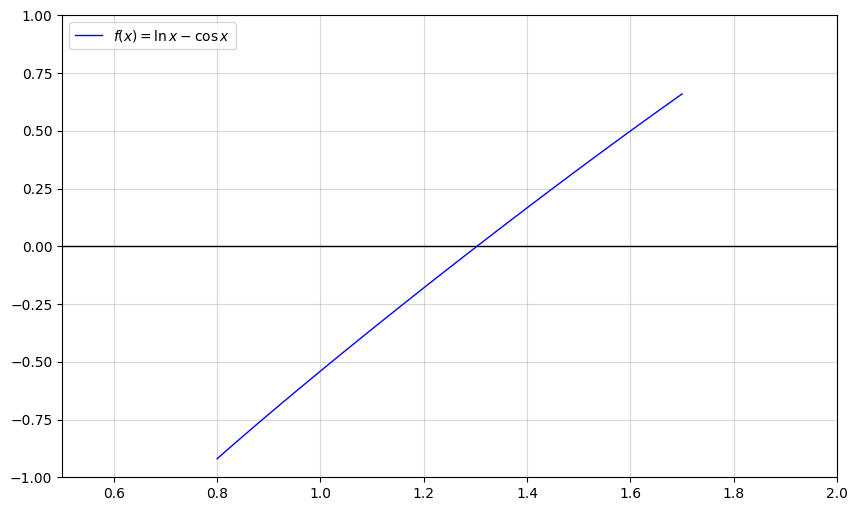

In [10]:
import matplotlib.pyplot as plt

def display_graph() -> None:
    x_vals = np.linspace(0.8, 1.7)
    y_vals = f(x_vals)

    plt.figure(figsize=(10, 6))
    plt.axhline(0, color='black', linewidth=1, linestyle='-')
    plt.axvline(0, color='black', linewidth=1, linestyle='-')
    plt.grid(True, linestyle='-', alpha=0.5)
    plt.xlim(0.5, 2.0)
    plt.ylim(-1.0, 1.0)
    plt.plot(x_vals, y_vals, linewidth=1, label=r'$f(x) = \ln x - \cos x$', color='blue')

    plt.legend(loc='upper left')
    plt.show()

display_graph()

### Проверка достаточных условий для примения методов

Исследуем непрерывность функции:
- $ln(x)$ определена и непрерывна при $\textit{x}>0$,
- $cos(x)$ определена и непрерывна при $\textit{x}∊R$,

$f(x)$ определена и непрерывна на $[0.8; 1.7]$.

Найдем первую и вторую производную:
- $f'(x)=\frac{1}{x}+sin(x)$,
- $f''(x)=-\frac{1}{x^2}+cos(x)$.

In [11]:
def df(x: float, c: float = 1) -> float:
    return 1 / x + np.sin(x)

def ddf(x: float, c: float = 1) -> float:
    return -1 / x**2 + np.cos(x)

Исследуем знак первой производной:

In [12]:
md(f"$f'(0.8)\\approx{(df(0.8)):.5f}$")
md(f"$f'(1.7)\\approx{(df(1.7)):.5f}$")

$f'(0.8)\approx1.96736$

$f'(1.7)\approx1.57990$

В обеих точках $f'(x)>0$ &rArr; $f(x)$ возрастает на интервале $[0.8; 1.7]$.

Исследуем знак второй производной:

In [13]:
md(f"$f''(0.8)\\approx{(ddf(0.8)):.5f}$")
md(f"$f''(1.7)\\approx{ddf((1.7)):.5f}$")

$f''(0.8)\approx-0.86579$

$f''(1.7)\approx-0.47487$

В обеих точках $f''(x)<0$ &rArr; $f(x)$ выпукла на интервале $[0.8; 1.7]$.

## Сужение/проверка интервала

Проверим свойства единственности корня на интервале изоляции $[0.8; 1.7]$:

In [14]:
md(f"$f(0.8)\\approx{(f(0.8)):.5f}$")
md(f"$f(1.7)\\approx{f((1.7)):.5f}$")

$f(0.8)\approx-0.91985$

$f(1.7)\approx0.65947$

Функция на концах интервала имеет разные знаки, первая и вторая производные не меняют знак, следовательно на интервале изоляции существует единственный корень.

Проверим выполнение неравенства $M\leq2m$ для выбора условия прекращения итерационного цикла:

In [15]:
M = max(abs(ddf(0.8)), abs(ddf(1.7)))
m = min(abs(df(0.8)), abs(df(1.7)))
md(f"Условие $M\\leq2m$ выполняется: ${M:.5f}<{(2 * m):.5f}$")

Условие $M\leq2m$ выполняется: $0.86579<3.15980$

## Решение с помощью комбинированного метода

Определим нулевое приближение для метода хорд:
- $f(a)<0; f(b)>0; f''(x)<0$ &rArr; $x=0.8$ - неподвижный конец интервала &rArr; $x_0=1.7$

In [16]:
md(f"$f(x)*f''(x)\\approx{(f(0.8) * ddf(1.7)):.5f}>0$")

$f(x)*f''(x)\approx0.43680>0$

In [17]:
def chord(x: float, a: float, c: float = 1) -> float:
    return x - (f(x, c) / (f(x, c) - f(a, c))) * (x - a)

Определим нулевое приближение для метода касательных Нютона:
- $f(a)<0; f(b)>0; f''(x)<0$ &rArr; $x=0.8$ - неподвижный конец интервала &rArr; $x_0=0.8$

In [18]:
def nw(x: float, c: float = 1) -> float:
    return x - f(x, c) / df(x, c)

In [19]:
def calc_comb(a: float, b: float, c: float = 1, eps: float = 1e-5):
    i, history = 0, []
    while True:
        i += 1
        a_n = nw(a, c)
        b_n = chord(b, a, c)
        history.append({ 'a': a, 'b': b, 'a_n': a_n, 'b_n': b_n })
        if abs(b_n - a_n) < eps:
            return (a_n + b_n) / 2, i, history
        a, b = a_n, b_n

In [20]:
x, i, history = calc_comb(0.8, 1.7)

In [21]:
md(f"Приближенное значение корня: ${x:.5f}$")
md(f"Количество итераций: ${i}$")

Приближенное значение корня: $1.30296$

Количество итераций: $3$

### Построение первых двух шагов комбинированного метода

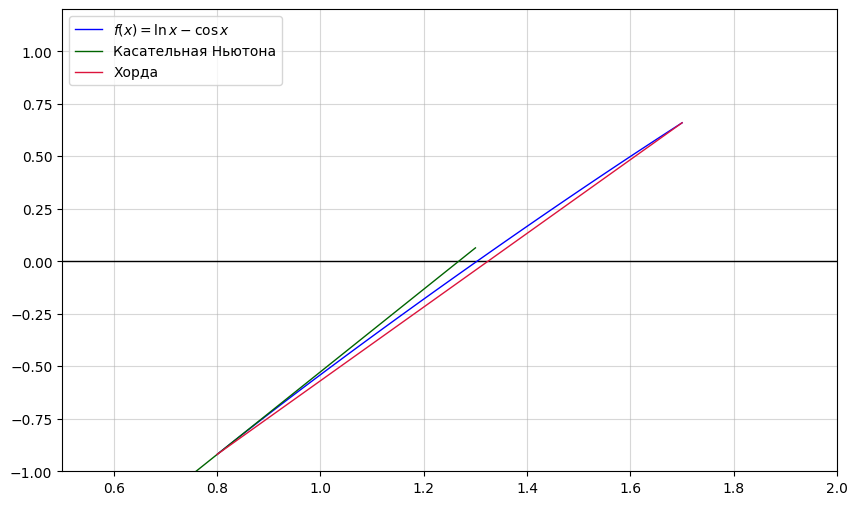

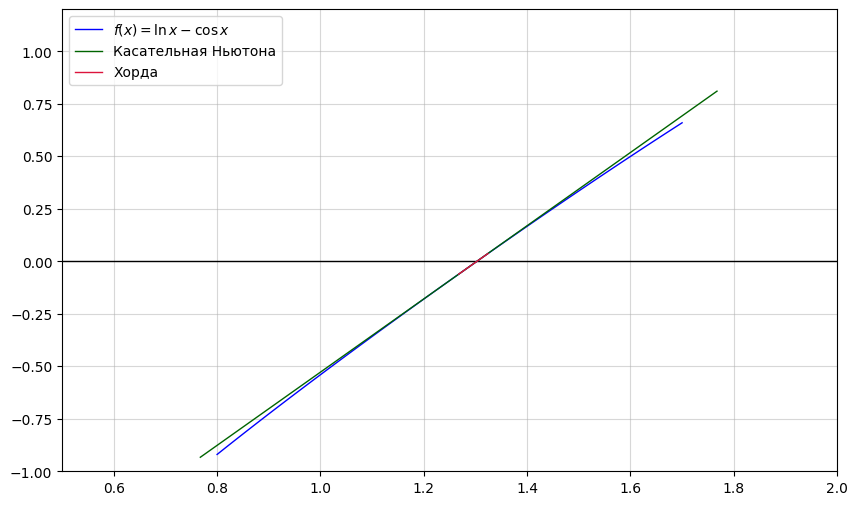

In [22]:
def display_two_steps(history):
    x_plot = np.linspace(0.8, 1.7)
    y_plot = f(x_plot)

    xlim = (0.5, 2.0)
    ylim = (-1.0, 1.2)

    for i in range(2):
        step = history[i]
        fig, ax = plt.subplots(figsize=(10, 6))
        ax.axhline(0, color='black', lw=1)
        ax.axvline(0, color='black', lw=1)
        ax.grid(True, alpha=0.5)
        ax.set_xlim(xlim)
        ax.set_ylim(ylim)
        ax.plot(x_plot, y_plot, lw=1, label=r'$f(x) = \ln x - \cos x$', color='blue')

        xa = step['a']
        xb = step['b']
        x_new = step['a_n']

        ya = f(xa)
        yb = f(xb)
        y_new = f(x_new)

        x_tan = np.linspace(max(0.5, xa - 0.5), min(2.0, xa + 0.5))
        y_tan = ya + df(xa) * (x_tan - xa)
        mask = (y_tan >= ylim[0] - 0.3) & (y_tan <= ylim[1] + 0.3)
        ax.plot(x_tan[mask], y_tan[mask], color='darkgreen', lw=1, label='Касательная Ньютона')

        x_chord = np.linspace(min(xa, xb), max(xa, xb))
        m = (yb - ya) / (xb - xa) if xb != xa else 0
        y_chord = ya + m * (x_chord - xa)
        ax.plot(x_chord, y_chord, color='crimson', lw=1, label='Хорда', zorder=5)

        ax.legend(loc='upper left')
        plt.show()

display_two_steps(history)

## Решение с помощью метода касательных Ньютона

$f(a)<0; f(b)>0; f''(x)<0$ &rArr; $x_0=0.8$

In [23]:
def calc_nw(x: float, c: float = 1, eps: float = 1e-5):
    i: int = 0
    while True:
        i += 1
        if x < 0:
            md(f"X не может быть меньше $0$")
            return 0, i
        x_n = nw(x, c)
        if abs(x_n - x) < eps:
            return x_n, i
        x = x_n

In [76]:
x, i = calc_nw(1.5)
md(f"Приближенное значение корня: ${x:.5f}$")
md(f"Количество итераций: ${i}$")

Приближенное значение корня: $1.30296$

Количество итераций: $3$

Выберем в качестве нулевого приближения неправильный конец интервала $x_0=1.7$:

In [77]:
x, i = calc_nw(1.7)
md(f"Приближенное значение корня: ${x:.5f}$")
md(f"Количество итераций: ${i}$")

Приближенное значение корня: $1.30296$

Количество итераций: $4$

При использовании неправильного конца интервала результат не изменился.

## Обусловленность задачи

В исходной уравнение добавим некоторый параметр $с$: $f(x)=ln(x)-с*cos(x)$.<br>
Найдем решения при $с=1.5$:

Комбинированный метод:

In [29]:
x, i, _ = calc_comb(0.8, 1.7, 1.5)
md(f"Приближенное значение корня: ${x:.5f}$")
md(f"Количество итераций: ${i}$")

Приближенное значение корня: $1.36290$

Количество итераций: $9$

Метод касательных Ньютона:

In [30]:
x, i = calc_nw(1.7, 1.5)
md(f"Приближенное значение корня: ${x:.5f}$")
md(f"Количество итераций: ${i}$")

Приближенное значение корня: $1.36290$

Количество итераций: $10$

При параметре $с=1.5$ приближенное значение корня незначительно увеличилось.

## Метод простых итераций

Найдем максимум первой производной на интервале $[0.8; 1.7]$:

In [31]:
md(f"$max|f'(x)|=N\\approx{(abs(max(df(0.8), df(1.7)))):.5f}$")

$max|f'(x)|=N\approx1.96736$

Возьмем коэфицент $k=1 > N/2$ Проверим условие сходимости:

In [32]:
md(f"$|\\phi'(0.8)|\\approx{(abs(1 - df(0.8) / 1)):.5f}\\leq1$")
md(f"$|\\phi'(1.7)|\\approx{(abs(1 - df(1.7) / 1)):.5f}\\leq1$")

$|\phi'(0.8)|\approx0.96736\leq1$

$|\phi'(1.7)|\approx0.57990\leq1$

Итерационный процесс сходится с двух сторон

In [60]:
def it(x: float, k: float) -> float:
    return x - f(x) / k

def phi(x: float, k: float) -> float:
    return abs(1 - df(x) / k)

def calc_it(x: float, k: float, eps: float = 1e-5):
    q = max(phi(0.8, k), phi(1.7, k))
    print(q)
    i: int = 0
    while True:
        i += 1
        if x < 0:
            md(f"X не может быть меньше $0$")
            return 0, i
        x_n = it(x, k)
        if abs(x - x_n) < (1 - q) / 1 * eps:
            return x_n, i
        x = x_n

In [61]:
x, i = calc_it(0.8, 1.8)
md(f"Приближенное значение корня: ${x:.5f}$")
md(f"Количество итераций: ${i}$")

0.12227771968326917


Приближенное значение корня: $1.30296$

Количество итераций: $5$

In [71]:
x, i = calc_it(0.8, 1.4)
md(f"Приближенное значение корня: ${x:.5f}$")
md(f"Количество итераций: ${i}$")

0.40525435064251636


Приближенное значение корня: $1.30296$

Количество итераций: $10$

In [74]:
x, i = calc_it(0.8, 3)
md(f"Приближенное значение корня: ${x:.5f}$")
md(f"Количество итераций: ${i}$")

0.4733666318099615


Приближенное значение корня: $1.30296$

Количество итераций: $14$

In [75]:
x, i = calc_it(0.8, 4)
md(f"Приближенное значение корня: ${x:.5f}$")
md(f"Количество итераций: ${i}$")

0.6050249738574711


Приближенное значение корня: $1.30296$

Количество итераций: $21$

Нарушим достаточное условие сходимости $k=0.5$:

In [ ]:
x, i = calc_it(0.8, 0.5)
md(f"Приближенное значение корня: ${x:.5f}$")
md(f"Количество итераций: ${i}$")

## Решение исходного уравнения в готовом пакете

Для решения исходного уравнения использовалась готовая математическая среда Wolfram Alpha. Результат найденного корня на интервале при заданной точности равна: $1.30296$, что является равным вычислениям с помощью комбинированного метода, метода касательных Ньютона, метода простых итераций.